# Current trial interval is divided by 'port entry'
- We need to develop the 'resting time' defined between port entry and port exit
- With 'port exit' information, we can analyse resting time specific DA and HPC activity

[definition idea](##definition) Find the hex exit (nearest three hex from the port). then concatenate with the previous port visit time fetched from the trial time interval. In case of last visit does not have exit, grab the last interval time and exclude from analysis. or just empty it and make sure screening the trial by their interval length

[output structure idea 1](##output_idea1) make a big interval list consist of valid resting time

[output structure idea 2](##output_idea2) add a colume of resting interval after each trial information, thereby grouping trials by conditions is enabled

[output analysis idea 1](##output_analysis1) SWR ripple alignment

- setup datajoint

In [3]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
import datajoint as dj

import spyglass
import spyglass.common as sgc
import spyglass.position as sgp
import spyglass.data_import as sgi
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from spyglass.utils.nwb_helper_fn import get_nwb_file
from spyglass.common import Nwbfile

from hexmaze import plot_hex_maze
from hex_maze_behavior import HexMazeBlock, HexPosition, HexPath, HexMazeChoice, HexMazeTrialHistory
from berke_fiber_photometry import FiberPhotometrySeries

print(sys.executable)
print("NumPy:", np.__version__)
print(spyglass.__file__)
print(spyglass.__version__)
# after git pull. make sure the location is /home/yshwang/code/spyglass/src/spyglass/__init__.py

# change to the upper level folder to detect dj_local_conf.json
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
dj.config.load("dj_local_conf.json")  # load config for database connection info

# ignore datajoint+jupyter async warnings
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)
warnings.simplefilter("ignore", category=UserWarning)

[2026-02-06 15:42:23,139][INFO]: DataJoint is configured from /home/yshwang/code/Hex-maze-spyglass/dj_local_conf.json


/home/yshwang/miniforge3/envs/spyglass/bin/python
NumPy: 1.26.4
/home/yshwang/code/spyglass/src/spyglass/__init__.py
0.5.5a2.dev28+g2d7bc523c.d20260113


- make sure your nwb has behavior info

In [7]:
nwb_file_name = "IM-1594_20230725.nwb"
nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)

# Confirm the datetime of the copied NWB file and the source script version
nwb_file_abspath = Nwbfile.get_abs_path(nwb_copy_file_name)
nwbf = get_nwb_file(nwb_file_abspath)
print(f"File created on {nwbf.file_create_date[0].strftime('%m/%d/%Y %H:%M:%S')}")
print(f"Source script version {nwbf.source_script}")

# Query the Nwbfile table to confirm the entry for the NWB file
display(sgc.Nwbfile & {"nwb_file_name": nwb_copy_file_name})
display(HexPath() & {'nwb_file_name': nwb_copy_file_name})

File created on 01/13/2026 09:31:52
Source script version jdb_to_nwb 2.1.3.dev0+g029276d9a.d20251210


nwb_file_name name of the NWB file,nwb_file_abs_path
IM-1594_20230725_.nwb,=BLOB=


pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_path_object_id
26383419-624b-7a2c-69c2-b84e8cebad32,IM-1594_20230725_.nwb,0,IM-1594_20230725_5TSKZS35YS.nwb,5db31461-728a-4a81-a31d-9e656fcf352c


## Definition

### 0. Fetch data from `HexMazeBlock` and `HexMazeBlock.Trial` tables

Both of these tables have the secondary key `interval_list_name`, so we can't do a regular join using `*`.

I have a function `HexMazeBlock().join_with_trial()` that automatically renames these to `block_interval_list_name` and `trial_interval_list_name` so we can join them

In [ ]:
nwb_key = {"nwb_file_name" : nwb_copy_file_name}

# mannually specify pos_merge_id
pos_merge_id = "26383419-624b-7a2c-69c2-b84e8cebad32"
hex_path_key = {"pos_merge_id": pos_merge_id}
# or fetch the pos_merge_id from HexPath table
# hex_path_key = (HexPath() & nwb_key).fetch("KEY")[0]


# Get hex path dataframe for the whole epoch
display(HexPath() & hex_path_key)
hex_path_df = (HexPath & hex_path_key).fetch1_dataframe()
display(hex_path_df)

# display(HexMazeBlock() & nwb_key) # block table
# display(HexMazeBlock.Trial() & nwb_key) # trial table
# display(HexMazeBlock().join_with_trial() & nwb_key) # block + trial table!

# TODO: Ask steph about how the reward port time is devided into two bridging trials
hex_path_df.loc[hex_path_df['epoch_trial_num']==3]

pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_path_object_id
26383419-624b-7a2c-69c2-b84e8cebad32,IM-1594_20230725_.nwb,0,IM-1594_20230725_5TSKZS35YS.nwb,5db31461-728a-4a81-a31d-9e656fcf352c


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion
id,,,,,,,,,,,,,,,
0,IM-1594_20230725_.nwb,0,1,1,1,19,12.743423,12.879184,0.135761,1,1,-1,5,optimal,chosen
1,IM-1594_20230725_.nwb,0,1,1,1,23,12.950297,13.726817,0.776520,2,1,-1,4,optimal,chosen
2,IM-1594_20230725_.nwb,0,1,1,1,28,13.794255,14.075289,0.281034,3,1,-1,3,optimal,chosen
3,IM-1594_20230725_.nwb,0,1,1,1,33,14.144213,14.144213,0.000000,4,1,-1,2,optimal,chosen
4,IM-1594_20230725_.nwb,0,1,1,1,28,14.207479,14.207479,0.000000,5,2,-1,3,optimal,chosen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932,IM-1594_20230725_.nwb,0,3,9,140,37,4158.090880,4158.298052,0.207172,21,1,16,4,optimal,chosen
4933,IM-1594_20230725_.nwb,0,3,9,140,32,4158.362117,4158.505761,0.143644,22,1,17,3,optimal,chosen
4934,IM-1594_20230725_.nwb,0,3,9,140,38,4158.569801,4158.778867,0.209066,23,1,18,2,optimal,chosen


In [31]:
hex_path_df['epoch_trial_num'].unique()

array([  1,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,   2,  20,
        21,  22,  23,  24,  25,  26,  27,  28,  29,   3,  30,  31,  32,
        33,  34,  35,  36,  37,  38,  39,   4,  40,  41,  42,  43,  44,
        45,  46,  47,  48,  49,   5,  50,  51,  52,  53,  54,  55,  56,
        57,  58,  59,   6,  60,  61,  62,   7,   8,   9,  63,  72,  73,
        74,  75,  76,  77,  78,  79,  80,  81,  64,  82,  83,  84,  85,
        86,  87,  88,  89,  90,  91,  65,  92,  93,  94,  95,  96,  97,
        98,  99, 100, 101,  66, 102, 103, 104, 105, 106, 107, 108, 109,
       110, 111,  67, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121,
        68, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131,  69,  70,
        71, 132, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 133,
       151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 134, 161, 162,
       163, 164, 165, 166, 167, 168, 169, 170, 135, 171, 172, 173, 174,
       175, 176, 177, 178, 179, 180, 136, 181, 182, 183, 184, 18

In [38]:
hex_path_df.loc[hex_path_df['epoch_trial_num']==192]

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion
id,,,,,,,,,,,,,,,
4809,IM-1594_20230725_.nwb,0,3,61,192,2,6338.700452,6344.553202,5.852751,1,1,0,20,optimal,start
4810,IM-1594_20230725_.nwb,0,3,61,192,49,6344.604282,6382.310271,37.705989,2,1,1,19,optimal,start
4811,IM-1594_20230725_.nwb,0,3,61,192,2,6382.364730,6384.219780,1.855049,3,2,0,20,optimal,start
4812,IM-1594_20230725_.nwb,0,3,61,192,49,6384.281342,6390.538587,6.257245,4,2,1,19,optimal,start
4813,IM-1594_20230725_.nwb,0,3,61,192,2,6390.603131,6391.432662,0.829530,5,3,0,20,optimal,start
4814,IM-1594_20230725_.nwb,0,3,61,192,49,6391.496861,6392.312428,0.815567,6,3,1,19,optimal,start
4815,IM-1594_20230725_.nwb,0,3,61,192,2,6392.415215,6400.350937,7.935722,7,4,0,20,optimal,start
4816,IM-1594_20230725_.nwb,0,3,61,192,49,6400.408160,6400.566469,0.158309,8,4,1,19,optimal,start
4817,IM-1594_20230725_.nwb,0,3,61,192,47,6400.615821,6400.823879,0.208058,9,1,2,18,optimal,start


### 1. Find port entry (rest entry) - distant-from-port hex entry (rest exit) times

In [41]:
print(hex_path_df.columns)

start_path_hexes = [38,47,32,42,43,33,28,39,5,6,7,8] # port exit hexes to catch
rest_intervals = []
rest_durations = []

# Get unique trials sorted
trials = sorted(hex_path_df['epoch_trial_num'].unique())

for i, trial in enumerate(trials):
    # Get current trial data
    current_trial_df = hex_path_df[hex_path_df['epoch_trial_num'] == trials[i]]
    
    # Rest entry time is always the last entry time of current trial
    rest_entry = current_trial_df['entry_time'].iloc[-1]
    
    # Determine rest exit time
    if i < len(trials) - 1:
        # For all but last trial: first entry into start_path_hexes in next trial
        next_trial_df = hex_path_df[hex_path_df['epoch_trial_num'] == trials[i+1]]
        path_in_start_hexes = next_trial_df[next_trial_df['hex'].isin(start_path_hexes)]
        rest_exit = path_in_start_hexes['entry_time'].iloc[0]
        exit_hex = path_in_start_hexes['hex'].iloc[0]
        exit_note = ""
    else:
        # For last trial: use exit time of last hex
        rest_exit = current_trial_df['exit_time'].iloc[-1]
        exit_hex = current_trial_df['hex'].iloc[-1]
        exit_note = " (unknown, using exit time of the last trial)"
    
    # Calculate duration
    rest_duration = rest_exit - rest_entry
    
    # Print info
    print(f"Trial {trial}: Rest entry at port {current_trial_df['hex'].iloc[-1]}, time = {rest_entry}")
    print(f"Trial {trial}: Rest exit at port {exit_hex}, time = {rest_exit}{exit_note}")
    print(f"Trial {trial} resting duration: {rest_duration:.2f} seconds")
    
    # Store results
    rest_intervals.append([rest_entry, rest_exit])
    rest_durations.append(rest_duration)

# Convert to arrays
rest_intervals = np.array(rest_intervals)
rest_durations = np.array(rest_durations)

print(f"\nRest intervals shape: {rest_intervals.shape}")
print(f"Rest durations shape: {rest_durations.shape}")    


Index(['nwb_file_name', 'epoch', 'block', 'block_trial_num', 'epoch_trial_num',
       'hex', 'entry_time', 'exit_time', 'duration', 'hex_in_trial',
       'hex_entry_num', 'hexes_from_start', 'hexes_from_end', 'hex_type',
       'maze_portion'],
      dtype='object')
Trial 1: Rest entry at port 3, time = 14.415850341744749
Trial 1: Rest exit at port 43, time = 18.672679231468614
Trial 1 resting duration: 4.26 seconds
Trial 2: Rest entry at port 1, time = 25.46726036272981
Trial 2: Rest exit at port 5, time = 31.24933693046642
Trial 2 resting duration: 5.78 seconds
Trial 3: Rest entry at port 2, time = 49.58766648743915
Trial 3: Rest exit at port 47, time = 74.56136216507012
Trial 3 resting duration: 24.97 seconds
Trial 4: Rest entry at port 1, time = 91.25761143712572
Trial 4: Rest exit at port 6, time = 99.88990644940614
Trial 4 resting duration: 8.63 seconds
Trial 5: Rest entry at port 2, time = 117.4885692220385
Trial 5: Rest exit at port 38, time = 124.4643219805818
Trial 5 restin

In [ ]:
# with this resting time intervals, we can then extract the corresponding photometry data for each trial and perform further analysis.

## output_idea1

In [50]:
HexMazeBlock.Trial() & nwb_key

nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,block_trial_num trial number within the block,interval_list_name descriptive name of this interval list,epoch_trial_num trial number within the epoch,reward if the rat got a reward,"start_port A, B, or C","end_port A, B, or C","opto_cond description of opto condition, if any (delay / no_delay)","poke_interval np.array of [poke_in, poke_out]",duration trial duration in seconds
IM-1594_20230725_.nwb,0,1,1,epoch0_block1_trial1,1,1,None,C,None,=BLOB=,4.31505
IM-1594_20230725_.nwb,0,1,2,epoch0_block1_trial2,2,0,C,A,None,=BLOB=,9.69626
IM-1594_20230725_.nwb,0,1,3,epoch0_block1_trial3,3,1,A,B,None,=BLOB=,42.6436
IM-1594_20230725_.nwb,0,1,4,epoch0_block1_trial4,4,0,B,A,None,=BLOB=,29.7039
IM-1594_20230725_.nwb,0,1,5,epoch0_block1_trial5,5,1,A,B,None,=BLOB=,21.2733
IM-1594_20230725_.nwb,0,1,6,epoch0_block1_trial6,6,0,B,A,None,=BLOB=,42.6143
IM-1594_20230725_.nwb,0,1,7,epoch0_block1_trial7,7,1,A,C,None,=BLOB=,93.6408
IM-1594_20230725_.nwb,0,1,8,epoch0_block1_trial8,8,0,C,A,None,=BLOB=,13.8418
IM-1594_20230725_.nwb,0,1,9,epoch0_block1_trial9,9,1,A,C,None,=BLOB=,71.1246
IM-1594_20230725_.nwb,0,1,10,epoch0_block1_trial10,10,1,C,A,None,=BLOB=,41.7461


## output_idea2

## output_analysis1

- fetch SWR data

In [43]:
import spyglass.ripple.v1 as sgrip
import spyglass.lfp.analysis.v1 as lfp_analysis
from spyglass.lfp.analysis.v1 import lfp_band
from spyglass.lfp import LFPOutput
from spyglass.common.common_ephys import Raw


nwb_file_name = "IM-1594_20230725.nwb"
lfp_electrode_group_name = "hippocampus" # name of the shanks
interval_list_name = "00_r1"
filter_name = "Ripple 150-250 Hz"

nwb_copy_file_name = get_nwb_copy_filename(nwb_file_name)
nwbf_key = {"nwb_file_name": nwb_copy_file_name}
rawdata = (Raw & nwbf_key).fetch_nwb()[0]["raw"]

sampling_rate, raw_interval_list_name = (Raw & nwbf_key).fetch1(
    "sampling_rate", "interval_list_name"
)

lfp_eg_key = {
    "nwb_file_name": nwb_copy_file_name,
    "lfp_electrode_group_name": lfp_electrode_group_name,
}

lfp_s_key = lfp_eg_key.copy()
lfp_s_key.update(
    {
        "target_interval_list_name": interval_list_name,
        "filter_name": "LFP 0-400 Hz",
        "filter_sampling_rate": sampling_rate,  # sampling rate of the data (Hz)
        "target_sampling_rate": 1_000,  # smpling rate of the lfp output (Hz)
    }
)

lfp_merge_id = (LFPOutput.LFPV1() & lfp_s_key).fetch1("merge_id")
lfp_key = {"merge_id": lfp_merge_id}
lfp_sampling_rate = LFPOutput.merge_get_parent(lfp_key).fetch1("lfp_sampling_rate")

In [46]:
from spyglass.position import PositionOutput

lfp_band_key = (
    lfp_analysis.LFPBandV1()
    & {
        "filter_name": filter_name,
        "nwb_file_name": nwb_copy_file_name,
        "lfp_band_sampling_rate": lfp_sampling_rate,
    }
).fetch1("KEY")

rip_sel_key = (sgrip.RippleLFPSelection & lfp_band_key).fetch1("KEY")

pos_key = {
    "nwb_file_name": nwb_copy_file_name,
    "trodes_pos_params_name": "berke_double_led_decoding",
    "interval_list_name": "pos 0 valid times",
}
pos_key = PositionOutput.merge_get_part(pos_key).fetch1("KEY")

key = {
    "ripple_param_name": "default_trodes",
    **rip_sel_key,
    "pos_merge_id": pos_key["merge_id"],
}

ripple_times = (sgrip.RippleTimesV1() & key).fetch1_dataframe()
ripple_band_df = (lfp_band.LFPBandV1() & lfp_band_key).fetch1_dataframe()

In [47]:
ripple_times

,start_time,end_time,duration,max_thresh,mean_zscore,median_zscore,max_zscore,min_zscore,area,total_energy,speed_at_start,speed_at_end,max_speed,min_speed,median_speed,mean_speed
id,,,,,,,,,,,,,,,,
0,41.883267,41.949000,0.065733,2.020905,1.677331,1.637911,4.299956,0.028122,0.111830,0.275629,0.235740,0.886918,0.886918,0.134092,0.394054,0.429370
1,41.976067,42.069833,0.093767,6.461072,3.427213,2.155421,8.988046,0.047556,0.324571,2.012527,1.293570,2.565420,2.565420,1.293570,1.979997,1.966668
2,43.266567,43.358400,0.091833,4.226286,2.269359,1.516911,4.405256,0.096957,0.210466,0.652837,1.780901,2.005864,2.016828,1.780901,1.914405,1.909747
3,64.656629,64.705928,0.049299,3.984702,2.536638,2.646575,5.060035,0.128279,0.127371,0.474231,1.337500,2.050280,2.050280,1.279417,1.400862,1.503395
4,66.381121,66.489385,0.108264,5.891132,2.498328,1.557006,6.844109,0.033461,0.272825,1.132959,2.716104,3.434567,3.434567,2.120665,2.406703,2.499453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1224,6323.302385,6323.422249,0.119863,4.291007,2.439061,2.403571,6.127710,0.019022,0.294684,1.016115,1.280229,0.437321,1.280229,0.437321,0.906605,0.886579
1225,6325.255965,6325.293664,0.037699,2.048153,1.713716,1.647191,3.516585,0.007198,0.066227,0.169285,2.170749,2.906803,2.906803,2.170749,2.531163,2.531140
1226,6334.108454,6334.233150,0.124697,3.373534,1.592119,1.214866,3.704825,0.049677,0.199962,0.476458,1.866000,0.511719,1.866000,0.146690,0.493242,0.715235


In [48]:
ripple_band_df

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
time,,,,,,,,,,,,,,,,,,,,,
12.703634,17,18,15,15,16,19,22,18,20,20,...,19,25,17,17,15,17,17,-36,14,15
12.704601,16,14,16,16,11,-4,28,19,32,58,...,-1,0,-5,6,2,-1,2,-750,1,10
12.705568,-6,-7,-3,-2,-8,-22,-2,-2,0,13,...,-27,-32,-27,-18,-17,-22,-20,-507,-17,-13
12.706534,-18,-15,-14,-7,-14,-11,-27,-16,-31,-50,...,-19,-23,-14,-20,-16,-15,-18,281,-15,-23
12.707501,-5,-3,-6,0,-1,10,-15,-8,-19,-41,...,17,18,18,6,7,12,7,580,6,-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6424.524093,22,23,21,17,19,13,13,23,12,22,...,13,16,13,13,13,18,14,19,15,18
6424.525059,31,29,21,16,21,10,16,19,17,35,...,21,19,20,27,25,27,27,-48,29,30
6424.526026,3,0,-3,-3,-1,-7,-1,-7,0,3,...,3,-1,2,8,7,4,8,-69,10,8


# *RAMP Pipeline*
1. Calculate average `z_scored_green_dFF` between each hex's `entry_time` and `exit_time` and add that column
2. Plot the ramp approaching to the goal (first, all of trials)
3. Get trial information based on conditions (rewarded? unrewarded? swr? no-swr? unrewarded_rewarded? rewarded_unrewarded?)
4. Plot the ramp given that information of trials

### 1.  Calculate average `z_scored_green_dFF` between each hex's `entry_time` and `exit_time` and add that column

In [4]:
def add_averaged_series_column(HexPath_df, phot_series, new_col_name: str):
    """
    Calculate the average z_scored_green_dFF between each hex's entry_time and exit_time.

    Parameters:
    HexPath_df (pd.DataFrame): DataFrame containing hex path data with 'entry_time' and 'exit_time' columns.
    phot_series (FiberPhotometryResponseSeries): Photometry series object containing timestamps and data.

    Returns:
    pd.DataFrame: Updated DataFrame with a new column specified by col_name.
    """
    df = HexPath_df.copy()
    avg_series_list = []

    timestamps = phot_series.get_timestamps()
    data = phot_series.data[:]

    for _, row in df.iterrows():
        entry_time = row['entry_time']
        exit_time = row['exit_time']

        # Find indices of timestamps within the entry and exit time
        indices = np.where((timestamps >= entry_time) & (timestamps <= exit_time))[0]

        if len(indices) > 0:
            avg_dFF = np.mean(data[indices])
        else:
            avg_dFF = np.nan  # No data in this interval

        avg_series_list.append(avg_dFF)

    df[new_col_name] = avg_series_list
    return df

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion
id,,,,,,,,,,,,,,,
0,IM-1478_20220726_.nwb,0,1,1,1,49,49.924743,50.526743,0.602,1,1,-1,1,optimal,chosen
1,IM-1478_20220726_.nwb,0,1,1,1,2,50.528743,54.334743,3.806,2,1,-1,0,optimal,chosen
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,IM-1478_20220726_.nwb,0,3,12,135,37,4363.960606,4364.056606,0.096,39,4,10,4,optimal,chosen
2966,IM-1478_20220726_.nwb,0,3,12,135,42,4364.058606,4364.368606,0.310,40,1,11,3,optimal,chosen
2967,IM-1478_20220726_.nwb,0,3,12,135,47,4364.370606,4364.686606,0.316,41,1,12,2,optimal,chosen


Text(0, 0.5, 'Photometry series data')

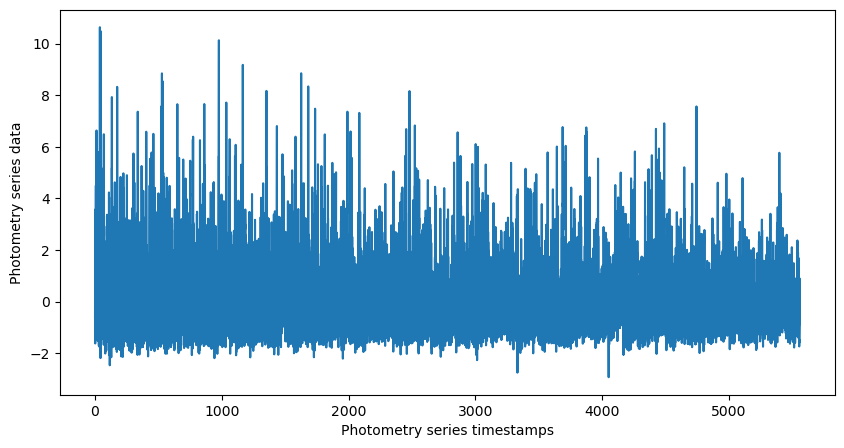

In [5]:
# Get hex path dataframe for the whole epoch
epoch_df = (HexPath & hex_path_key).fetch1_dataframe()
display(epoch_df)

# Fetch the a specific nwb FiberPhotometryResponseSeries object by name
series_name = "z_scored_green_dFF"
phot_series = FiberPhotometrySeries.fetch_series(nwb_file_name=nwb_file_name, series_name=series_name)

plt.figure(figsize = (10, 5))
plt.plot(phot_series.get_timestamps(), phot_series.data[:])
plt.xlabel('Photometry series timestamps')
plt.ylabel('Photometry series data')

In [6]:
epoch_df_dff = add_averaged_series_column(epoch_df, phot_series, new_col_name='avg_z_scored_green_dFF')
display(epoch_df_dff)

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
0,IM-1478_20220726_.nwb,0,1,1,1,49,49.924743,50.526743,0.602,1,1,-1,1,optimal,chosen,2.605692
1,IM-1478_20220726_.nwb,0,1,1,1,2,50.528743,54.334743,3.806,2,1,-1,0,optimal,chosen,0.967906
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start,0.817231
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start,-0.224777
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start,0.400566
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,IM-1478_20220726_.nwb,0,3,12,135,37,4363.960606,4364.056606,0.096,39,4,10,4,optimal,chosen,-0.872425
2966,IM-1478_20220726_.nwb,0,3,12,135,42,4364.058606,4364.368606,0.310,40,1,11,3,optimal,chosen,-0.941935
2967,IM-1478_20220726_.nwb,0,3,12,135,47,4364.370606,4364.686606,0.316,41,1,12,2,optimal,chosen,-0.544739


In [7]:
def filter_df_by_duration(HexPath_df, max_duration: float = 1.0):
    """
    Filter epochs based on minimum duration.
    """
    df = HexPath_df.copy()
    filtered_df = df[df['duration'] <= max_duration]
    
    return filtered_df

In [8]:
epoch_df_dff_duration_filtered = filter_df_by_duration(epoch_df_dff, max_duration = 1)
epoch_df_dff_duration_filtered

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
0,IM-1478_20220726_.nwb,0,1,1,1,49,49.924743,50.526743,0.602,1,1,-1,1,optimal,chosen,2.605692
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start,0.817231
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start,-0.224777
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start,0.400566
5,IM-1478_20220726_.nwb,0,1,2,2,32,55.802743,56.110743,0.308,4,1,3,11,optimal,start,-0.403063
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2964,IM-1478_20220726_.nwb,0,3,12,135,32,4363.298606,4363.958606,0.660,38,5,11,3,optimal,chosen,-0.853009
2965,IM-1478_20220726_.nwb,0,3,12,135,37,4363.960606,4364.056606,0.096,39,4,10,4,optimal,chosen,-0.872425
2966,IM-1478_20220726_.nwb,0,3,12,135,42,4364.058606,4364.368606,0.310,40,1,11,3,optimal,chosen,-0.941935


### 2. Plot the ramp approaching to the goal (first, all of trials)
- epoch_df_dff has `hexes_from_end`, `hex_type`, and `hex_entry_num` to filter the hex to combine the `avg_z_scored_green_dff`
- we average the `avg_z_scored_green_dff` on the same of `hexes_from_end` when `'hex_type' == 'optimal'`, for now, ignore `hex_entry_num`

In [9]:
def weighted_mean_and_sem(HexPath_df, series_col: str = 'avg_z_scored_green_dFF', duration_col: str = 'duration'):
    """
    Compute duration-weighted mean and an approximate weighted SEM for one DataFrame (no grouping).
    Returns a pandas Series with keys: weighted_mean, weighted_sem, count, total_duration.
    """
    # drop rows with missing values in either column
    df = HexPath_df.dropna(subset=[series_col, duration_col])
    x = df[series_col].to_numpy(dtype=float)
    w = df[duration_col].to_numpy(dtype=float)
    n = x.size
    sum_w = w.sum()

    if n == 0:
        return pd.Series({'weighted_mean': np.nan, 'weighted_sem': np.nan, 'count': 0, 'total_duration': 0.0})

    # if total weight is zero we cannot compute a weighted mean/sem
    if sum_w == 0:
        return pd.Series({'weighted_mean': np.nan, 'weighted_sem': np.nan, 'count': int(n), 'total_duration': float(sum_w)})

    # weighted mean
    weighted_mean = np.average(x, weights=w)

    # population weighted variance: sum(w*(x-mu)^2)/sum(w)
    wvar = np.average((x - weighted_mean) ** 2, weights=w)
    sum_w2 = (w ** 2).sum()

    # effective sample size and sem
    n_eff = (sum_w ** 2) / sum_w2 if sum_w2 > 0 else np.nan
    weighted_sem = np.sqrt(wvar / n_eff) if (not np.isnan(n_eff) and n_eff > 0) else np.nan

    return pd.Series({
        'weighted_mean': float(weighted_mean),
        'weighted_sem': float(weighted_sem),
        'count': int(n),
        'total_duration': float(sum_w)
    })

In [10]:
def group_series_by_hex_path_col(HexPath_df, series_name: str, hex_path_col: str, hex_type=['optimal', 'non_optimal', 'dead_end'], maze_portion=['chosen', 'start', 'choice_point', 'unchosen'], pick_max_hex_entry_num=False):
    """
    Group series_name by hexes_from_end for rows with given hex_type.

    Parameters:
    - HexPath_df: pd.DataFrame with columns ['block','block_trial_num','hexes_from_end',
      'hex_type','hex_entry_num','averaged_series (manual column name)']
    - hex_type: filter by these hex_types, they have ['optimal', 'dead_end', 'non_optimal'] (default ['optimal'])
    - pick_max_hex_entry_num: if True, for each (block, block_trial_num, hexes_from_end)
      keep only the row with the max hex_entry_num (useful to pick last revisit)

    Returns:
    - dict mapping hexes_from_end -> list of series_col (NaNs are dropped)
    """

    df = HexPath_df.copy()

    if pick_max_hex_entry_num:
        # keep the last visit per trial/hexes_from_end (largest hex_entry_num)
        df = df.sort_values('hex_entry_num').drop_duplicates(
            subset=['block', 'block_trial_num', 'hexes_from_end'],
            keep='last'
        )

    # filter by hex_type
    if hex_type:
        df = df[df['hex_type'].isin(hex_type)]

    if maze_portion:
        df = df[df['maze_portion'].isin(maze_portion)]

    # group by hexes_from_end and 
    series_by_hexes_from_end = (df
             .groupby(hex_path_col)
             .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))

    return series_by_hexes_from_end

In [11]:
# testing the data that passed the duration filter
dff_by_hexes_from_end = group_series_by_hex_path_col(epoch_df_dff_duration_filtered, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
display(dff_by_hexes_from_end)

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,-0.243148,0.267650,6.0,3.534000
1,0.241697,0.064128,138.0,25.587999
2,0.080407,0.048862,134.0,35.591999
3,-0.103586,0.052023,137.0,41.877999
4,-0.168542,0.053297,139.0,51.041998
5,-0.172322,0.052196,145.0,36.171999
6,-0.293723,0.049149,127.0,46.063999
7,-0.425240,0.048764,122.0,47.325998
8,-0.427733,0.043358,143.0,47.011999


In [12]:
def plot_series_during_port_approach(series_by_hexes_from_end, series_col:str='weighted_mean', exclude_end_port=False, max_hexes_from_end=False, plot_sem=True, figsize=(10,5), figtitle:str='Averaged series'):

    df = series_by_hexes_from_end.copy()
    
    if exclude_end_port:
        df = df.loc[df.index != 0]

    if max_hexes_from_end:
        df = df.loc[df.index <= max_hexes_from_end]
        
    plt.figure(figsize=figsize)
    plt.plot(df.index, df[series_col], label=series_col, color='C2')
    if plot_sem:
        plt.fill_between(df.index, df[series_col] - df['weighted_sem'], df[series_col] + df['weighted_sem'], color='C2', alpha=0.25, label='± weighted sem')
    plt.xlabel('Distance from port (hexes)')
    plt.ylabel(figtitle)
    # reverse x axis so it goes from max -> min
    plt.xlim(df.index.max(), df.index.min())
    plt.xticks(np.arange(df.index.max(), df.index.min()-1, -1))
    plt.legend()
    plt.show()

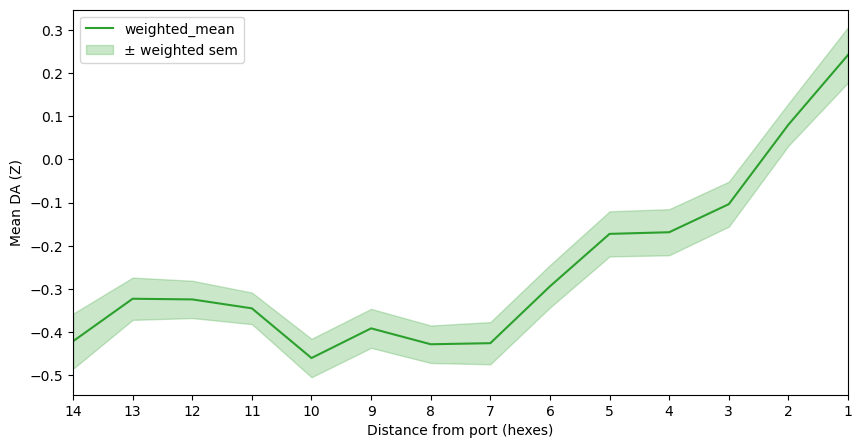

In [13]:
plot_series_during_port_approach(dff_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=True, max_hexes_from_end=14, figtitle='Mean DA (Z)') 

# Back To *RAMP* with Steph's newly populated table!
### 3. Get trial information based on conditions (rewarded? unrewarded? swr? no-swr? unrewarded_rewarded? rewarded_unrewarded?)

In [14]:
TrialHistory_df = pd.DataFrame((HexMazeTrialHistory() * HexMazeChoice() * HexMazeBlock().join_with_trial() & {'nwb_file_name': nwb_file_name}).fetch(as_dict=True)) # * sgc.Session()
TrialHistory_df.head()

,nwb_file_name,epoch,block,block_trial_num,port_visit_1prev_rwd,port_visit_2prev_rwd,port_visit_3prev_rwd,port_visit_1prev_same_path,port_visit_2prev_same_path,port_visit_3prev_same_path,...,num_trials,task_type,trial_interval_list_name,epoch_trial_num,reward,start_port,end_port,opto_cond,poke_interval,duration
0,IM-1478_20220726_.nwb,0,1,2,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial2,2,0,B,A,None,"[69.228, 74.12250240000337]",19.7859
1,IM-1478_20220726_.nwb,0,1,3,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial3,3,0,A,B,None,"[106.528, 108.44085760000348]",34.3184
2,IM-1478_20220726_.nwb,0,1,4,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial4,4,1,B,C,None,"[132.54, 140.2933951999992]",31.8525
3,IM-1478_20220726_.nwb,0,1,5,0,0,0,0,0,0,...,62,probability change,epoch0_block1_trial5,5,0,C,B,None,"[152.896, 164.43391999999434]",24.1405
4,IM-1478_20220726_.nwb,0,1,6,0,0,0,1,0,0,...,62,probability change,epoch0_block1_trial6,6,1,B,A,None,"[174.56, 189.60823039999605]",25.1743


In [15]:
def get_prev_current_dfs_by_conditions(
    HexPath_df: pd.DataFrame,
    HexMazeTrialHistory_df: pd.DataFrame,
    conditions: dict = None,
    *,
    skip_missing_filter_columns: bool = True,
) :
    """
    Return (prev_trial_df, current_trial_df) filtered from HexMazeTrialHistory_df according
    to the provided condition lists. Each parameter corresponds to a column in
    HexMazeTrialHistory_df and is used with `.isin(...)` when not None.

    prev_trial_df contains the rows whose `epoch_trial_num` equals
    current_trial_df['epoch_trial_num'] - 1 (i.e., the immediate previous trial).
    Both returned DataFrames are sorted by 'epoch_trial_num'.

    Parameters:
    - HexMazeTrialHistory_df: DataFrame with trial history (must contain relevant columns
      including 'epoch_trial_num').
    - Any of the keyword parameters: list of allowed values for that column. If
      a parameter is None, that column is not used for filtering.

    Returns:
    - prev_trial_df, current_trial_df (both pd.DataFrame)
    """
    hex_df = HexPath_df.copy()
    trial_df = HexMazeTrialHistory_df.copy() 
    
    if 'epoch_trial_num' not in trial_df.columns or 'epoch_trial_num' not in hex_df.columns:
        raise ValueError("Both inputs must contain 'epoch_trial_num'")

    # Apply filters based on provided conditions 
    for col, allowed_values in conditions.items():
        if allowed_values is not None:
            trial_df = trial_df[trial_df[col].isin(allowed_values)]
            
    # Create current and previous trial DataFrames
    current_epoch_trial_num = trial_df.epoch_trial_num.values
    prev_epoch_trial_num = current_epoch_trial_num - 1
    
    print(f"Total previous/current trials after filtering: {len(current_epoch_trial_num)} each")
    
    current_HexPath_df = hex_df[hex_df['epoch_trial_num'].isin(current_epoch_trial_num)].copy()
    prev_HexPath_df = hex_df[hex_df['epoch_trial_num'].isin(prev_epoch_trial_num)].copy()
    
    return prev_HexPath_df, current_HexPath_df
    

In [16]:
conditions_to_filter = {
    'port_visit_2prev_rwd': [0],
    'port_visit_1prev_rwd': [1],
    'trials_since_port_visit' : [2, 3],
}

prev_epoch_df_dff_duration_condition_filtered, current_epoch_df_dff_duration_condition_filtered = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_to_filter)
print(conditions_to_filter)
display(prev_epoch_df_dff_duration_condition_filtered.head())
display(current_epoch_df_dff_duration_condition_filtered.head())    

Total previous/current trials after filtering: 17 each
{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
94,IM-1478_20220726_.nwb,0,1,6,6,2,164.43474,164.87674,0.442,1,1,0,14,optimal,start,-1.089305
95,IM-1478_20220726_.nwb,0,1,6,6,49,164.87874,165.06674,0.188,2,1,1,13,optimal,start,-1.346668
96,IM-1478_20220726_.nwb,0,1,6,6,38,165.06874,165.39474,0.326,3,1,2,12,optimal,start,-0.419976
97,IM-1478_20220726_.nwb,0,1,6,6,32,165.39674,165.70474,0.308,4,1,3,11,optimal,start,-0.284117
98,IM-1478_20220726_.nwb,0,1,6,6,37,165.70674,165.85674,0.150,5,1,4,10,optimal,start,-0.340675


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
109,IM-1478_20220726_.nwb,0,1,7,7,1,189.608739,190.076739,0.468,1,1,0,16,optimal,start,-1.069629
110,IM-1478_20220726_.nwb,0,1,7,7,4,190.078739,190.786739,0.708,2,1,1,15,optimal,start,-0.607818
111,IM-1478_20220726_.nwb,0,1,7,7,1,190.788739,191.104739,0.316,3,2,0,16,optimal,start,-0.060217
112,IM-1478_20220726_.nwb,0,1,7,7,4,191.106739,191.538739,0.432,4,2,1,15,optimal,start,-0.189375
113,IM-1478_20220726_.nwb,0,1,7,7,6,191.540739,191.754739,0.214,5,1,2,14,optimal,start,-1.031131


#### 4. Plot the ramp given that information of trials

In [17]:
prev_dff_by_hexes_from_end = group_series_by_hex_path_col(prev_epoch_df_dff_duration_condition_filtered, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
current_dff_by_hexes_from_end = group_series_by_hex_path_col(current_epoch_df_dff_duration_condition_filtered, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
print(conditions_to_filter)
print(prev_dff_by_hexes_from_end)
print(current_dff_by_hexes_from_end)

{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}
                weighted_mean  weighted_sem  count  total_duration
hexes_from_end                                                    
1                    0.355908      0.167429   17.0           2.940
2                    0.246059      0.136605   17.0           4.670
3                   -0.081203      0.122796   16.0           4.156
4                   -0.353055      0.091561   16.0           6.058
5                   -0.175248      0.212729   19.0           4.264
6                   -0.260851      0.164891   18.0           6.056
7                   -0.392362      0.121294   18.0           8.370
8                   -0.511695      0.090675   19.0           5.758
9                   -0.396475      0.135095   21.0           9.316
10                  -0.518082      0.103983   19.0           6.070
11                  -0.417747      0.074203   14.0           4.090
12                  -0.252850      

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))
/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


In [18]:
def plot_two_series_during_port_approach(prev_series_by_hexes_from_end, current_series_by_hexes_from_end, series_col:str='weighted_mean', exclude_end_port=False, max_hexes_from_end=False, plot_sem=True, figsize=(10,5), figtitle:str='Average z-scored green dFF'):

    prev_df = prev_series_by_hexes_from_end.copy()
    current_df = current_series_by_hexes_from_end.copy()
    
    if exclude_end_port:
        prev_df = prev_df.loc[prev_df.index != 0]
        current_df = current_df.loc[current_df.index != 0]

    if max_hexes_from_end:
        prev_df = prev_df.loc[prev_df.index <= max_hexes_from_end]
        current_df = current_df.loc[current_df.index <= max_hexes_from_end]
        
    plt.figure(figsize=figsize)
    plt.plot(prev_df.index, prev_df[series_col], label='Previous', color='C7')
    plt.plot(current_df.index, current_df[series_col], label='Current', color='C0')
    if plot_sem:
        plt.fill_between(prev_df.index, prev_df[series_col] - prev_df['weighted_sem'], prev_df[series_col] + prev_df['weighted_sem'], color='C7', alpha=0.25, label='± weighted sem')
        plt.fill_between(current_df.index, current_df[series_col] - current_df['weighted_sem'], current_df[series_col] + current_df['weighted_sem'], color='C0', alpha=0.25, label='± weighted sem')
    plt.xlabel('Hexes from end')
    plt.ylabel(figtitle)
    # reverse x axis so it goes from max -> min
    plt.xlim(prev_df.index.max(), prev_df.index.min())
    plt.xticks(np.arange(prev_df.index.max(), prev_df.index.min()-1, -1))
    plt.legend()
    plt.show()

{'port_visit_2prev_rwd': [0], 'port_visit_1prev_rwd': [1], 'trials_since_port_visit': [2, 3]}


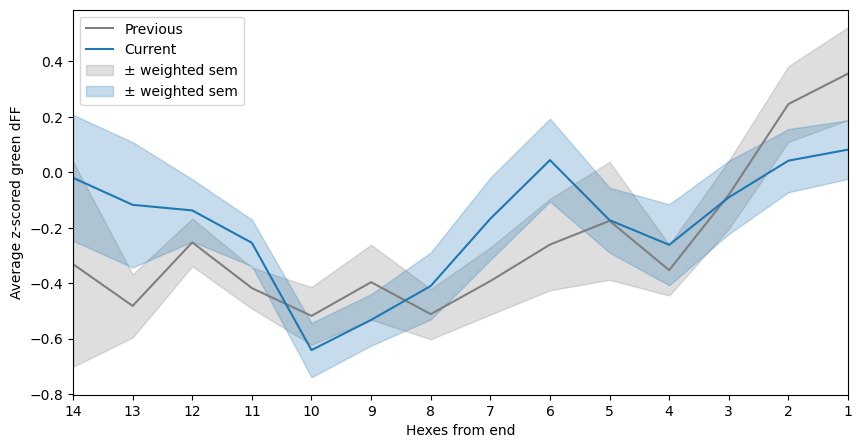

In [19]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

### trying another condition

In [20]:
conditions_to_filter = {
    'port_visit_2prev_rwd': [1],
    'port_visit_1prev_rwd': [0],
    'trials_since_port_visit' : [2, 3],
}

prev_epoch_df_dff_duration_condition_filtered, current_epoch_df_dff_duration_condition_filtered = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_to_filter)
print(conditions_to_filter)
display(prev_epoch_df_dff_duration_condition_filtered.head())
display(current_epoch_df_dff_duration_condition_filtered.head())    

Total previous/current trials after filtering: 18 each
{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
247,IM-1478_20220726_.nwb,0,1,12,12,1,347.890734,348.216734,0.326,1,1,0,14,optimal,start,-0.559797
249,IM-1478_20220726_.nwb,0,1,12,12,6,349.558734,349.748734,0.190,3,1,2,12,optimal,start,0.039041
250,IM-1478_20220726_.nwb,0,1,12,12,8,349.750734,350.212734,0.462,4,1,3,11,optimal,start,-0.813839
251,IM-1478_20220726_.nwb,0,1,12,12,10,350.214734,350.316734,0.102,5,1,4,10,optimal,start,-1.482311
252,IM-1478_20220726_.nwb,0,1,12,12,13,350.318734,350.698734,0.380,6,1,5,9,optimal,start,-1.109214


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
262,IM-1478_20220726_.nwb,0,1,13,13,2,354.438734,354.946734,0.508,1,1,0,16,optimal,start,-0.119720
263,IM-1478_20220726_.nwb,0,1,13,13,49,354.948734,354.954734,0.006,2,1,1,15,optimal,start,-0.351828
264,IM-1478_20220726_.nwb,0,1,13,13,2,354.956734,355.220734,0.264,3,2,0,16,optimal,start,0.338873
265,IM-1478_20220726_.nwb,0,1,13,13,49,355.222734,355.290734,0.068,4,2,1,15,optimal,start,2.204304
268,IM-1478_20220726_.nwb,0,1,13,13,38,360.898734,361.414734,0.516,7,1,2,14,optimal,start,-0.133880


In [21]:
prev_dff_by_hexes_from_end = group_series_by_hex_path_col(prev_epoch_df_dff_duration_condition_filtered, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
current_dff_by_hexes_from_end = group_series_by_hex_path_col(current_epoch_df_dff_duration_condition_filtered, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
print(conditions_to_filter)
print(prev_dff_by_hexes_from_end)
print(current_dff_by_hexes_from_end)

{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}
                weighted_mean  weighted_sem  count  total_duration
hexes_from_end                                                    
1                    0.336730      0.171599   18.0           3.166
2                    0.115103      0.183214   18.0           4.158
3                   -0.090112      0.128156   18.0           5.196
4                   -0.209490      0.148586   16.0           6.726
5                   -0.273860      0.103431   17.0           4.122
6                   -0.231688      0.145229   15.0           5.306
7                   -0.479987      0.149232   16.0           5.768
8                   -0.391727      0.115836   16.0           4.954
9                   -0.428178      0.097182   16.0           6.428
10                  -0.386558      0.110432   16.0           3.310
11                  -0.300571      0.106279   20.0           8.070
12                  -0.489457      

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))
/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


{'port_visit_2prev_rwd': [1], 'port_visit_1prev_rwd': [0], 'trials_since_port_visit': [2, 3]}


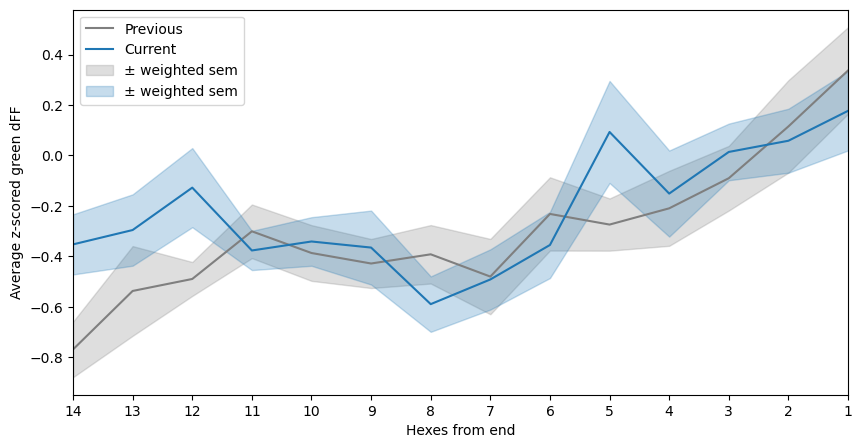

In [22]:
print(conditions_to_filter)
plot_two_series_during_port_approach(prev_dff_by_hexes_from_end, current_dff_by_hexes_from_end, max_hexes_from_end=14, figtitle='Average z-scored green dFF')

## speed fun. what if I want to plot with different conditions?

In [23]:
conditions_a_90 = {
    'end_port': ['A'],
    'p_a': [90.0],
}

conditions_a_50 = {
    'end_port': ['A'],
    'p_a': [50.0],
}

conditions_a_10 = {
    'end_port': ['A'],
    'p_a': [10.0],
}

_, current_to_90 = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_a_90)
_, current_to_50 = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_a_50)
_, current_to_10 = get_prev_current_dfs_by_conditions(epoch_df_dff_duration_filtered, TrialHistory_df, conditions_a_10)
display(current_to_90.head())
display(current_to_50.head())
display(current_to_10.head())

Total previous/current trials after filtering: 20 each
Total previous/current trials after filtering: 16 each
Total previous/current trials after filtering: 4 each


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start,0.817231
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start,-0.224777
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start,0.400566
5,IM-1478_20220726_.nwb,0,1,2,2,32,55.802743,56.110743,0.308,4,1,3,11,optimal,start,-0.403063
6,IM-1478_20220726_.nwb,0,1,2,2,37,56.112743,56.396743,0.284,5,1,4,10,optimal,start,-0.255451


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
1335,IM-1478_20220726_.nwb,0,2,1,63,3,1663.942692,1664.418692,0.476,1,1,0,16,optimal,start,-1.156955
1336,IM-1478_20220726_.nwb,0,2,1,63,48,1664.420692,1664.698692,0.278,2,1,1,15,optimal,start,-0.891511
1337,IM-1478_20220726_.nwb,0,2,1,63,43,1664.700692,1665.056692,0.356,3,1,2,16,non_optimal,start,-0.865199
1338,IM-1478_20220726_.nwb,0,2,1,63,39,1665.058692,1665.276692,0.218,4,1,3,15,non_optimal,start,-0.550300
1339,IM-1478_20220726_.nwb,0,2,1,63,34,1665.278692,1665.938692,0.660,5,1,4,14,non_optimal,start,-0.504747


,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF
id,,,,,,,,,,,,,,,,
2646,IM-1478_20220726_.nwb,0,3,1,124,2,3840.162623,3840.738623,0.576,1,1,0,14,optimal,start,-0.678752
2647,IM-1478_20220726_.nwb,0,3,1,124,49,3840.740623,3841.140623,0.400,2,1,1,13,optimal,start,-0.488826
2652,IM-1478_20220726_.nwb,0,3,1,124,47,3847.130623,3847.564623,0.434,7,1,2,12,optimal,start,-0.939892
2653,IM-1478_20220726_.nwb,0,3,1,124,49,3847.566623,3847.808623,0.242,8,2,1,13,optimal,start,-0.511456
2655,IM-1478_20220726_.nwb,0,3,1,124,49,3851.612623,3852.460623,0.848,10,3,1,13,optimal,start,-0.443442


In [24]:
dff_by_hexes_from_end_a_90 = group_series_by_hex_path_col(current_to_90, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
dff_by_hexes_from_end_a_50 = group_series_by_hex_path_col(current_to_50, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
dff_by_hexes_from_end_a_10 = group_series_by_hex_path_col(current_to_10, hex_path_col='hexes_from_end', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))
/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))
/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: D

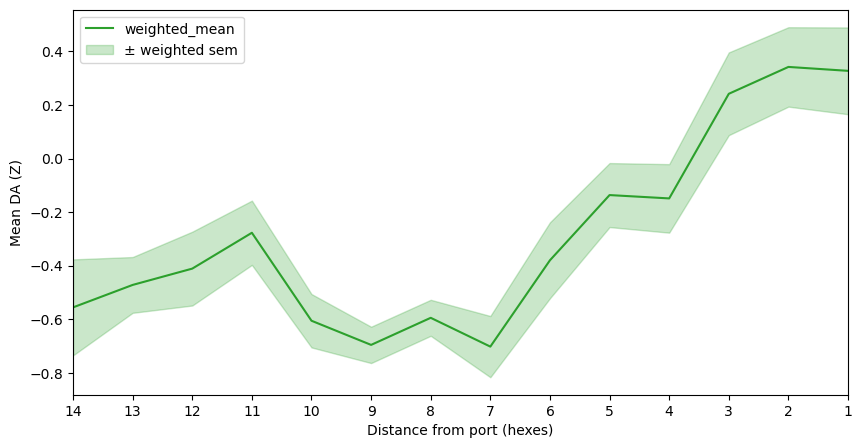

In [25]:
plot_series_during_port_approach(dff_by_hexes_from_end_a_90, series_col='weighted_mean', exclude_end_port=True, max_hexes_from_end=14, figtitle='Mean DA (Z)') 

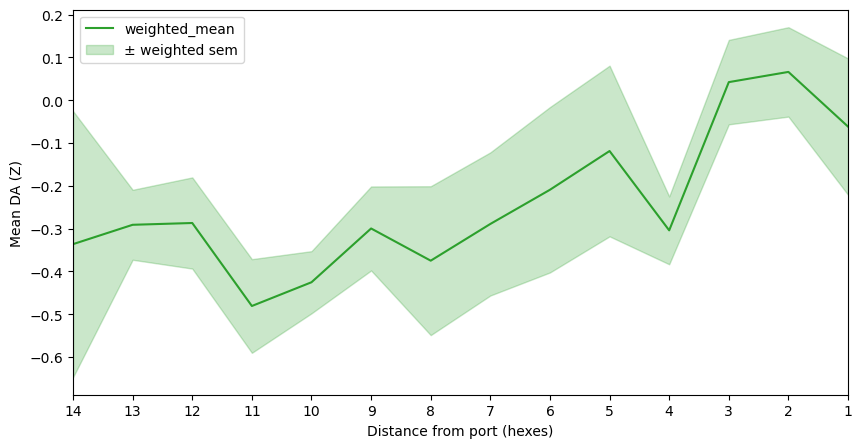

In [26]:
plot_series_during_port_approach(dff_by_hexes_from_end_a_50, series_col='weighted_mean', exclude_end_port=True, max_hexes_from_end=14, figtitle='Mean DA (Z)') 

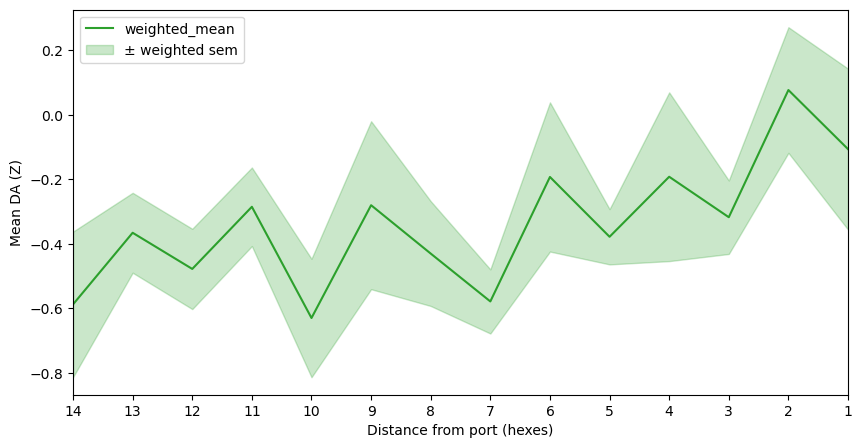

In [27]:
plot_series_during_port_approach(dff_by_hexes_from_end_a_10, series_col='weighted_mean', exclude_end_port=True, max_hexes_from_end=14, figtitle='Mean DA (Z)') 

# Speed plot
1. Directly using epoch_df and it's duration with size of the hex (13 cm)


In [28]:
def add_speed_column_by_duration(HexPath_df, new_col_name: str, hex_size: int = 13):
    """
    Add a speed column computed as hex_size / duration.
    Args:
        HexPath_df: DataFrame with a 'duration' column.
        new_col_name: name for the new speed column.
        hex_size: size (distance) of a hex (default 13).
    """
    df = HexPath_df.copy()
    speeds = []

    for _, row in df.iterrows():
        duration = row.get('duration', np.nan)
        try:
            duration = float(duration)
        except Exception:
            duration = np.nan

        if np.isfinite(duration) and duration > 0:
            speed = hex_size / duration
        else:
            speed = np.nan

        speeds.append(speed)

    df[new_col_name] = speeds
    return df

In [29]:
epoch_df_dff_speed = add_speed_column_by_duration(epoch_df_dff, hex_size=13, new_col_name='speed')
epoch_df_dff_speed

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF,speed
id,,,,,,,,,,,,,,,,,
0,IM-1478_20220726_.nwb,0,1,1,1,49,49.924743,50.526743,0.602,1,1,-1,1,optimal,chosen,2.605692,21.594685
1,IM-1478_20220726_.nwb,0,1,1,1,2,50.528743,54.334743,3.806,2,1,-1,0,optimal,chosen,0.967906,3.415660
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start,0.817231,20.833334
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start,-0.224777,53.719010
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start,0.400566,21.885523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,IM-1478_20220726_.nwb,0,3,12,135,37,4363.960606,4364.056606,0.096,39,4,10,4,optimal,chosen,-0.872425,135.416671
2966,IM-1478_20220726_.nwb,0,3,12,135,42,4364.058606,4364.368606,0.310,40,1,11,3,optimal,chosen,-0.941935,41.935485
2967,IM-1478_20220726_.nwb,0,3,12,135,47,4364.370606,4364.686606,0.316,41,1,12,2,optimal,chosen,-0.544739,41.139242


In [30]:
speed_by_hexes_from_end = group_series_by_hex_path_col(epoch_df_dff_speed, hex_path_col='hexes_from_end', series_name='speed', hex_type=['optimal','choice_point'])
display(speed_by_hexes_from_end)

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,1.859942,0.405145,138.0,964.545969
1,43.292396,10.706111,141.0,42.339999
2,44.690356,1.797558,137.0,39.851999
3,34.765860,3.529434,143.0,53.471998
4,11.770392,4.355508,163.0,180.027994
5,18.449323,12.347842,158.0,111.331996
6,20.424641,3.101883,144.0,91.653997
7,17.149473,2.633656,147.0,111.431996
8,20.068831,4.754223,157.0,101.699997


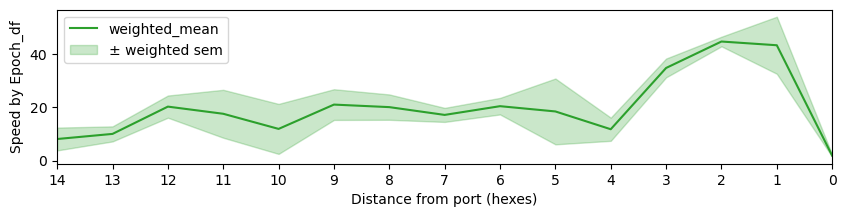

In [31]:
plot_series_during_port_approach(speed_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=False, max_hexes_from_end=14, figtitle='Speed by Epoch_df', figsize=(10,2)) 

2. Using velocity data from HexPosition table

In [32]:
from hex_maze_behavior import HexPosition

pos_key = {
    'pos_merge_id': "cfe6c111-1aa1-a41d-858c-f307e7a53b7c", 
    'nwb_file_name': 'IM-1478_20220726_.nwb', 
    'epoch': 0
}

display(HexPosition() & pos_key)

# Fetch rat's position + assigned hex
hex_and_pos_df = (HexPosition() & pos_key).fetch_hex_and_position_dataframe()
display(hex_and_pos_df)

pos_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_assignment_object_id
cfe6c111-1aa1-a41d-858c-f307e7a53b7c,IM-1478_20220726_.nwb,0,IM-1478_20220726_QVH88J6G2L.nwb,6713169f-da4e-412f-93c5-e709fce6ad7f


[19:24:43][WARNING] Spyglass: Upsampled position data, frame indices are invalid. Setting add_frame_ind=False


,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,hex_including_sides,distance_from_centroid
time,,,,,,,,,
49.924743,48.875865,126.927501,-2.828533,-6.552273,-11.494208,13.230612,49,49,6.594894
49.926743,48.855970,126.885491,-2.826981,-6.491748,-11.364589,13.088036,49,49,6.555677
49.928743,48.836074,126.843481,-2.825451,-6.430658,-11.232507,12.943052,49,49,6.516555
49.930743,48.816178,126.801471,-2.823943,-6.369021,-11.098029,12.795729,49,49,6.477530
49.932743,48.796282,126.759461,-2.822456,-6.306857,-10.961224,12.646141,49,49,6.438604
...,...,...,...,...,...,...,...,...,...
4373.816606,33.987062,129.762182,2.767999,5.172852,-6.221110,8.090773,2,2,6.777932
4373.818606,34.000927,129.758267,2.770006,5.240502,-6.331527,8.218947,2,2,6.763533
4373.820606,34.014791,129.754352,2.772013,5.307450,-6.441350,8.346258,2,2,6.749134


In [33]:
def add_averaged_speed_column(HexPath_df, HexPosition_df, new_col_name: str):
    """
    Calculate the average speed between each hex's entry_time and exit_time.

    Parameters:
    HexPath_df (pd.DataFrame): DataFrame containing hex path data with 'entry_time' and 'exit_time' columns.
    HexPosition_df (pd.DataFrame): DataFrame containing position data with timestamps and speed.

    Returns:
    pd.DataFrame: Updated DataFrame with a new column specified by col_name.
    """
    df = HexPath_df.copy()
    avg_series_list = []

    timestamps = HexPosition_df.index.values
    data = HexPosition_df.speed.values

    for _, row in df.iterrows():
        entry_time = row['entry_time']
        exit_time = row['exit_time']

        # Find indices of timestamps within the entry and exit time
        indices = np.where((timestamps >= entry_time) & (timestamps <= exit_time))[0]

        if len(indices) > 0:
            avg_speed = np.mean(data[indices])
        else:
            avg_speed = np.nan  # No data in this interval

        avg_series_list.append(avg_speed)

    df[new_col_name] = avg_series_list
    return df

In [34]:
epoch_df_dff_speed_avg = add_averaged_speed_column(epoch_df_dff_speed, hex_and_pos_df, new_col_name='avg_speed')
epoch_df_dff_speed_avg

,nwb_file_name,epoch,block,block_trial_num,epoch_trial_num,hex,entry_time,exit_time,duration,hex_in_trial,hex_entry_num,hexes_from_start,hexes_from_end,hex_type,maze_portion,avg_z_scored_green_dFF,speed,avg_speed
id,,,,,,,,,,,,,,,,,,
0,IM-1478_20220726_.nwb,0,1,1,1,49,49.924743,50.526743,0.602,1,1,-1,1,optimal,chosen,2.605692,21.594685,4.528278
1,IM-1478_20220726_.nwb,0,1,1,1,2,50.528743,54.334743,3.806,2,1,-1,0,optimal,chosen,0.967906,3.415660,5.705526
2,IM-1478_20220726_.nwb,0,1,2,2,2,54.336743,54.960743,0.624,1,1,0,14,optimal,start,0.817231,20.833334,14.179046
3,IM-1478_20220726_.nwb,0,1,2,2,49,54.962743,55.204743,0.242,2,1,1,13,optimal,start,-0.224777,53.719010,40.036868
4,IM-1478_20220726_.nwb,0,1,2,2,38,55.206743,55.800743,0.594,3,1,2,12,optimal,start,0.400566,21.885523,21.198948
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2965,IM-1478_20220726_.nwb,0,3,12,135,37,4363.960606,4364.056606,0.096,39,4,10,4,optimal,chosen,-0.872425,135.416671,33.813254
2966,IM-1478_20220726_.nwb,0,3,12,135,42,4364.058606,4364.368606,0.310,40,1,11,3,optimal,chosen,-0.941935,41.935485,32.235046
2967,IM-1478_20220726_.nwb,0,3,12,135,47,4364.370606,4364.686606,0.316,41,1,12,2,optimal,chosen,-0.544739,41.139242,39.522115


In [35]:
avg_speed_by_hexes_from_end = group_series_by_hex_path_col(epoch_df_dff_speed_avg, hex_path_col='hexes_from_end', series_name='avg_speed', hex_type=['optimal','choice_point'])
display(avg_speed_by_hexes_from_end)

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hexes_from_end,,,,
0,3.804943,0.243669,138.0,964.545969
1,29.231592,5.769726,141.0,42.339999
2,39.311151,1.220829,137.0,39.851999
3,27.556015,1.610110,143.0,53.471998
4,13.328939,2.834455,163.0,180.027994
5,12.238388,4.737219,158.0,111.331996
6,19.510704,2.406745,144.0,91.653997
7,15.403089,1.630327,147.0,111.431996
8,16.541069,3.105567,157.0,101.699997


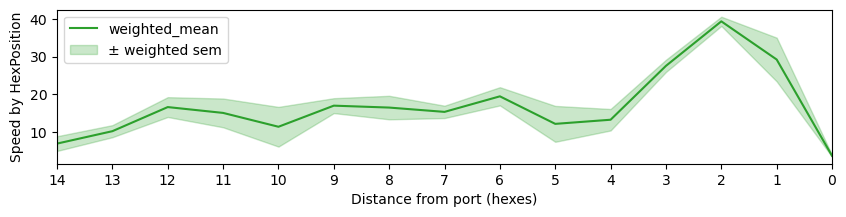

In [36]:
plot_series_during_port_approach(avg_speed_by_hexes_from_end, series_col='weighted_mean', exclude_end_port=False, max_hexes_from_end=14, figtitle='Speed by HexPosition', figsize=(10,2)) 

# Why not plotting maze with dff signal?

In [55]:
# testing the data that passed the duration filter
dff_by_hex = group_series_by_hex_path_col(epoch_df_dff_duration_filtered, hex_path_col='hex', series_name='avg_z_scored_green_dFF', hex_type=['optimal'])
display(dff_by_hex)

/tmp/ipykernel_3235003/1730269804.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grouped_df: weighted_mean_and_sem(grouped_df, series_name, 'duration')))


,weighted_mean,weighted_sem,count,total_duration
hex,,,,
1,-0.514087,0.118091,39.0,20.563999
2,-0.422303,0.108629,58.0,22.071999
3,-0.529778,0.101435,27.0,12.692000
4,-0.305660,0.112464,77.0,20.381999
6,-0.112800,0.068284,77.0,24.149999
8,-0.086072,0.061184,79.0,26.597999
10,-0.320557,0.113978,22.0,4.870000
11,-0.186419,0.076206,74.0,23.935999
13,-0.150984,0.187208,21.0,5.702000


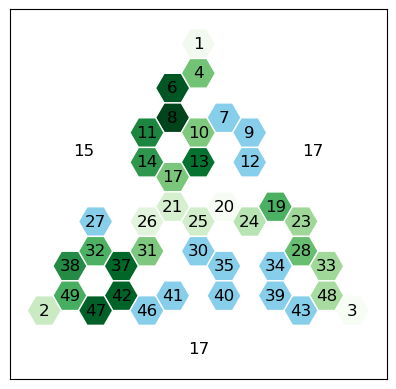

In [56]:
from hexmaze import plot_hex_maze

config = TrialHistory_df.config_id[0]
d = dict(zip(dff_by_hex.index, dff_by_hex['weighted_mean']))
plot_hex_maze(config, color_by = d, show_barriers = False, show_choice_points = False, colormap = 'Greens')